In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(867)

# Loading

In [3]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

# Model Free Analysis

In [4]:
# settings
d = 3
i = 12

# get pcRNA names
pcRNA_names = adata_pcRNA.var['GeneName'].tolist()

# initialize result dataframes
MF_ind_df = pd.DataFrame(index=pcRNA_names)
MF_int_df = pd.DataFrame(index=pcRNA_names)
corr_df = pd.DataFrame(index=pcRNA_names)

# select miRNA
miRNA = adata_miRNA[:, i].var['GeneName'].iloc[0]
print(miRNA)

# initialize dataset -------------------------------------------------------
data = SDP_miRNA.dataset.Dataset()

# construct dataset with default: miRNA paired with all mRNA
data.construct_dataset_adata(
    adata_miRNA[:, i],
    adata_pcRNA,
    beta
)

# bootstrap
data.bootstrap(d=d)

# OB & AL estimates: point and interval ------------------------------------
OB_corrs, AL_corrs = SDP_miRNA.correlation.compute_correlations(data)

# store
corr_df[f'{miRNA}_OB'] = OB_corrs[:, 0]
corr_df[f'{miRNA}_OB_min'] = OB_corrs[:, 1]
corr_df[f'{miRNA}_OB_max'] = OB_corrs[:, 2]
corr_df[f'{miRNA}_AL'] = AL_corrs[:, 0]
corr_df[f'{miRNA}_AL_min'] = AL_corrs[:, 1]
corr_df[f'{miRNA}_AL_max'] = AL_corrs[:, 2]

# model free independence test ---------------------------------------------
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data, d=d)
MF_ind.analyse_dataset()

# extract results
status = np.array([sol['status'] for sol in MF_ind.result_dict.values()])

# store
MF_ind_df[f'{miRNA}_status'] = status

# select indices of interacting pairs --------------------------------------
int_idxs = np.arange(status.size)[status == "INFEASIBLE"]

# reduce gene queries to these
gene_queries = [
    [[0], [int(i)]] for i in int_idxs
]

# store previous total
full_query_total = data.total_gene_queries

# update dataset
data.gene_queries = gene_queries
data.total_gene_queries = len(gene_queries)
data.moment_bounds = data.moment_bounds[:, int_idxs, :]

# model free interacting test (including Hit & Run)
MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data, d=d)
MF_int.analyse_dataset()

# Hit & Run correlations
HAR_points, HAR_intervals = MF_int.compute_dataset_correlation()

# Hit & Run midpoint: useful statistic
HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

# embedd MF int results (only on interacting pairs) into array of all pairs
HAR_all = np.empty((full_query_total, 3)) * np.nan
HAR_all[int_idxs, 0] = HAR_intervals[:, 0]
HAR_all[int_idxs, 1] = HAR_intervals[:, 1]
HAR_all[int_idxs, 2] = HAR_mid

# store
MF_int_df[f'{miRNA}_HAR_min'] = HAR_all[:, 0]
MF_int_df[f'{miRNA}_HAR_max'] = HAR_all[:, 1]
MF_int_df[f'{miRNA}_HAR_mid'] = HAR_all[:, 2]

# write results ------------------------------------------------------------
MF_ind_df.to_csv(f"Results/RISC/independent_MF.csv")
MF_int_df.to_csv(f"Results/RISC/interacting_MF.csv")
corr_df.to_csv(f"Results/RISC/correlation.csv")

MIR3655


  1%|          | 1/104 [00:01<01:56,  1.13s/it]c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
  4%|▍         | 41/959 [00:41<15:20,  1.00s/it]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 11%|█         | 102/959 [01:43<15:18,  1.07s/it]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


...

Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 89%|████████▊ | 850/959 [00:18<00:02, 36.73it/s]

Computation failed: 'NoneType' object is not iterable


 92%|█████████▏| 887/959 [00:19<00:01, 44.51it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 93%|█████████▎| 893/959 [00:19<00:01, 48.28it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 959/959 [00:20<00:00, 46.40it/s]


# Birth Death Analysis

In [14]:
class RISCBirthDeathOptimization(SDP_miRNA.optimization.Optimization):

    def __init__(self, dataset, **kwargs):

        # preset settings
        constraints = SDP_miRNA.constraints.Constraint(
            moment_bounds=True,
            moment_matrices=True,
            moment_equations=True
        )
        reactions = [
            "1",
            "xs[0]",
            "1",
            "xs[1]",
            "xs[0] * xs[1]"
        ]
        vrs = np.array([
            [ 1,  0],
            [-1,  0],
            [ 0,  1],
            [ 0, -1],
            [ 0, -1]
        ])
        db = 2
        R = 5
        S = 2
        U = []

        # default fixed rate
        if not ('rate_fixed' in kwargs.keys()):
            kwargs['rate_fixed'] = [(1, 1)]

        # initialize superclass
        super().__init__(
            dataset,
            constraints,
            reactions,
            vrs,
            db,
            R,
            S,
            U,
            **kwargs
        )

In [15]:
# RISC birth death model
RISC_BD = RISCBirthDeathOptimization(data, d=3, time_limit=30, total_time_limit=30)
RISC_BD.analyse_dataset()

100%|██████████| 959/959 [02:10<00:00,  7.37it/s]


In [50]:
# initialize result dataframes
RISC_BD_df = pd.DataFrame(index=pcRNA_names)

# extract status
status_BD = np.array([sol['status'] for sol in RISC_BD.result_dict.values()])

# embedd into array of all pairs
status_BD_all = (np.empty(full_query_total) * np.nan).astype(object)
status_BD_all[int_idxs] = status_BD

# store
RISC_BD_df[f'{miRNA}_status'] = status_BD_all

In [ ]:
# write to file
#RISC_BD_df.to_csv(f"Results/RISC/RISC_BD.csv")

In [75]:
RISC_BD_df.value_counts()

MIR3655_status
OPTIMAL           559
INFEASIBLE        400
Name: count, dtype: int64

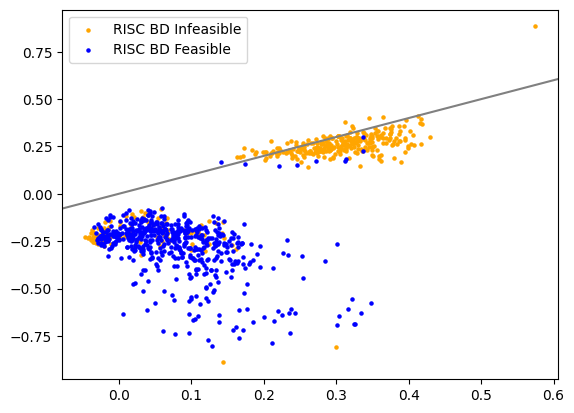

In [46]:
mask_BD = (RISC_BD_df == "INFEASIBLE").values.squeeze()
plt.scatter(
    corr_df[f'{miRNA}_OB'][mask_BD],
    MF_int_df[f'{miRNA}_HAR_mid'][mask_BD],
    s=5,
    color="orange",
    label="RISC BD Infeasible"
);
plt.scatter(
    corr_df[f'{miRNA}_OB'][~mask_BD],
    MF_int_df[f'{miRNA}_HAR_mid'][~mask_BD],
    s=5,
    color="blue",
    label="RISC BD Feasible"
);
plt.axline([0]*2, [0.1]*2, color="grey")
plt.legend()
plt.show()

## Intersection idea

In [88]:
# select feasible BD pairs
mask_1 = (RISC_BD_df[f'{miRNA}_status'] =="OPTIMAL").values.squeeze()

# select strong interactions
mask_2 = (MF_int_df[f'{miRNA}_HAR_mid'] < -0.5).values.squeeze()
mask_3 = (MF_int_df[f'{miRNA}_HAR_mid'] > -0.75).values.squeeze()

# combine
mask = mask_1 & mask_2 & mask_3

# select indices
select_idxs = np.arange(mask.size)[mask]

In [89]:
# construct dataset with these pairs
data = SDP_miRNA.dataset.Dataset()
data.construct_dataset_adata(
    adata_miRNA[:, 12],
    adata_pcRNA[:, select_idxs],
    beta
)

# bootstrap
data.bootstrap(d=d)

100%|██████████| 1/1 [00:01<00:00,  1.40s/it]


In [115]:
def objective_function_constructor(minimize=True):
    
    if minimize:
        def objective_function(opt, model, variables):
            return variables['k'][0]
    else:
        def objective_function(opt, model, variables):
            return -variables['k'][0]

    return objective_function

In [116]:
# RISC birth death model: minimize k_tx of miRNA
RISC_BD_min = RISCBirthDeathOptimization(
    data,
    d=3,
    time_limit=30,
    total_time_limit=30,
    objective_function=objective_function_constructor(minimize=True)
)
RISC_BD_min.analyse_dataset()

100%|██████████| 48/48 [00:03<00:00, 13.40it/s]


In [117]:
# RISC birth death model: maximize k_tx of miRNA
RISC_BD_max = RISCBirthDeathOptimization(
    data,
    d=3,
    time_limit=30,
    total_time_limit=30,
    objective_function=objective_function_constructor(minimize=False)
)
RISC_BD_max.analyse_dataset()

100%|██████████| 48/48 [00:03<00:00, 12.52it/s]


In [118]:
k_tx_min = np.array([var_dict[-1]['k[0]'] for var_dict in RISC_BD_min.feasible_values_dict.values()])
k_tx_max = np.array([var_dict[-1]['k[0]'] for var_dict in RISC_BD_max.feasible_values_dict.values()])

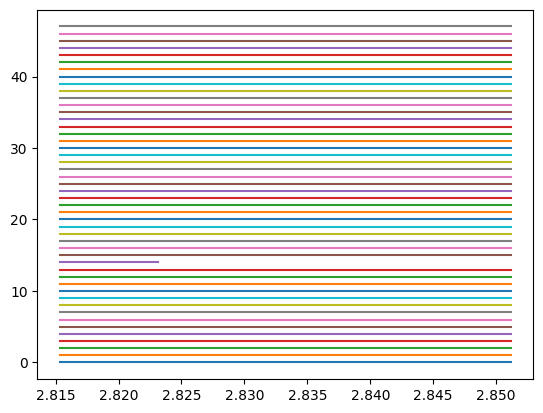

In [119]:
plt.plot(
    [k_tx_min, k_tx_max],
    [np.arange(48), np.arange(48)]
);

### almost identical already?

In [120]:
float(np.max(k_tx_min)), float(np.min(k_tx_max))

(2.8153444112001735, 2.8231640045372712)

Select a value in interval

In [122]:
k_tx_R = 2.82

In [123]:
# find feasible points with this fixed value
# simulate and compute correlations between mRNA
# check if they are consistent with those observed in the data

# Telegraph Analysis

In [47]:
class RISCTelegraphOptimization(SDP_miRNA.optimization.Optimization):

    def __init__(self, dataset, **kwargs):

        # preset settings
        constraints = SDP_miRNA.constraints.Constraint(
            moment_bounds=True,
            moment_matrices=True,
            moment_equations=True,
            unobserved_constraints=True
        )
        reactions = [
            "1",
            "xs[0]",
            "1 - xs[2]",
            "xs[2]",
            "xs[2]",
            "xs[1]",
            "xs[0] * xs[1]"
        ]
        vrs = np.array([
            [ 1,  0,  0],
            [-1,  0,  0],
            [ 0,  0,  1],
            [ 0,  0, -1],
            [ 0,  1,  0],
            [ 0, -1,  0],
            [ 0, -1,  0]
        ])
        db = 2
        R = 7
        S = 3
        U = [2]

        # default fixed rate
        if not ('rate_fixed' in kwargs.keys()):
            kwargs['rate_fixed'] = [(1, 1)]

        # initialize superclass
        super().__init__(
            dataset,
            constraints,
            reactions,
            vrs,
            db,
            R,
            S,
            U,
            **kwargs
        )

In [58]:
# select indices of RISC BD infeasible pairs
BD_inf_idxs = np.arange(status_BD.size)[status_BD == "INFEASIBLE"]

# reduce gene queries to these
gene_queries = [
    [[0], [int(i)]] for i in BD_inf_idxs
]

# update dataset
data.gene_queries = gene_queries
data.total_gene_queries = len(gene_queries)
data.moment_bounds = data.moment_bounds[:, BD_inf_idxs, :]

In [61]:
# RISC telgraph model
RISC_TE = RISCTelegraphOptimization(data, d=3, time_limit=30, total_time_limit=30)
RISC_TE.analyse_dataset()

  0%|          | 0/400 [00:00<?, ?it/s]

  4%|▍         | 17/400 [06:11<2:19:31, 21.86s/it]


KeyboardInterrupt: 

In [62]:
RISC_TE.result_dict

{0: {'status': 'TIME_LIMIT', 'time': 30.163000106811523, 'cuts': 6},
 1: {'status': 'OPTIMAL', 'time': 0.14899992942810059, 'cuts': 4},
 2: {'status': 'OPTIMAL', 'time': 1.7839999198913574, 'cuts': 5},
 3: {'status': 'OPTIMAL', 'time': 0.8350002765655518, 'cuts': 3},
 4: {'status': 'TIME_LIMIT', 'time': 30.003000020980835, 'cuts': 0},
 5: {'status': 'OPTIMAL', 'time': 1.6539998054504395, 'cuts': 5},
 6: {'status': 'OPTIMAL', 'time': 2.5789997577667236, 'cuts': 4},
 7: {'status': 'TIME_LIMIT', 'time': 30.12399983406067, 'cuts': 0},
 8: {'status': 'TIME_LIMIT', 'time': 30.004000186920166, 'cuts': 0},
 9: {'status': 'TIME_LIMIT', 'time': 30.00600004196167, 'cuts': 0},
 10: {'status': 'TIME_LIMIT', 'time': 30.005000114440918, 'cuts': 0},
 11: {'status': 'TIME_LIMIT', 'time': 30.003000020980835, 'cuts': 0},
 12: {'status': 'TIME_LIMIT', 'time': 30.003000020980835, 'cuts': 0},
 13: {'status': 'TIME_LIMIT', 'time': 30.00599980354309, 'cuts': 0},
 14: {'status': 'TIME_LIMIT', 'time': 30.006000